In [5]:
import pandas as pd
url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"
df = pd.read_csv(url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.shape

(392, 9)

In [7]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 27.7 KB


In [9]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [10]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

In [11]:
df.replace("?",pd.NA,inplace=True)
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

In [12]:
df = df.drop(columns= ["name"])
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,1
388,44.0,4,97.0,52,2130,24.6,82,2
389,32.0,4,135.0,84,2295,11.6,82,1
390,28.0,4,120.0,79,2625,18.6,82,1


In [13]:
y = df["mpg"]
X = df.drop(columns= ["mpg"])
X.head(), y.head()

(   cylinders  displacement  horsepower  weight  acceleration  year  origin
 0          8         307.0         130    3504          12.0    70       1
 1          8         350.0         165    3693          11.5    70       1
 2          8         318.0         150    3436          11.0    70       1
 3          8         304.0         150    3433          12.0    70       1
 4          8         302.0         140    3449          10.5    70       1,
 0    18.0
 1    15.0
 2    18.0
 3    16.0
 4    17.0
 Name: mpg, dtype: float64)

In [14]:
corr = df.corr()
corr["mpg"]

mpg             1.000000
cylinders      -0.777618
displacement   -0.805127
horsepower     -0.778427
weight         -0.832244
acceleration    0.423329
year            0.580541
origin          0.565209
Name: mpg, dtype: float64

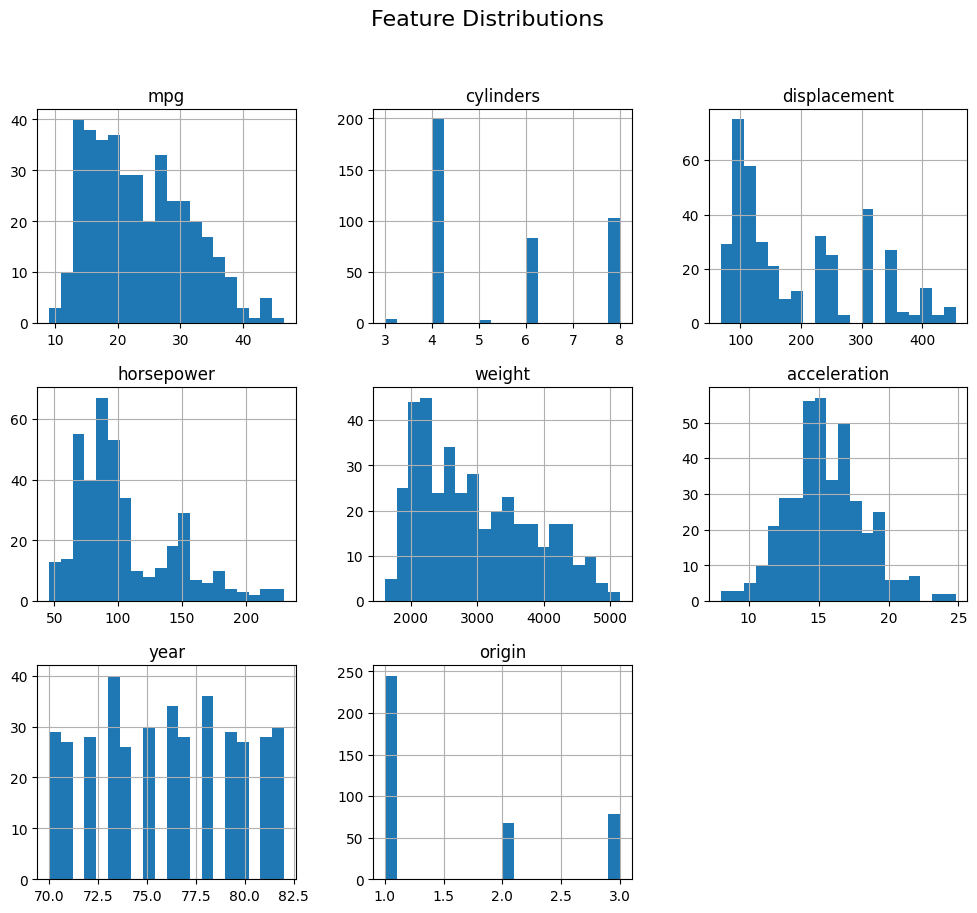

In [15]:
import matplotlib.pyplot as plt

df.hist(figsize = (12, 10), bins = 20)
plt.suptitle("Feature Distributions", fontsize = 16)
plt.show()

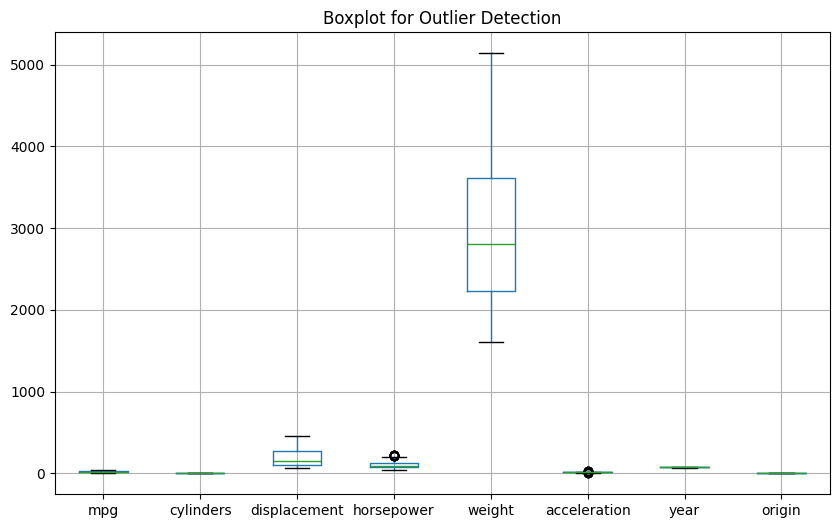

In [16]:
plt.figure(figsize = (10, 6))
df.boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

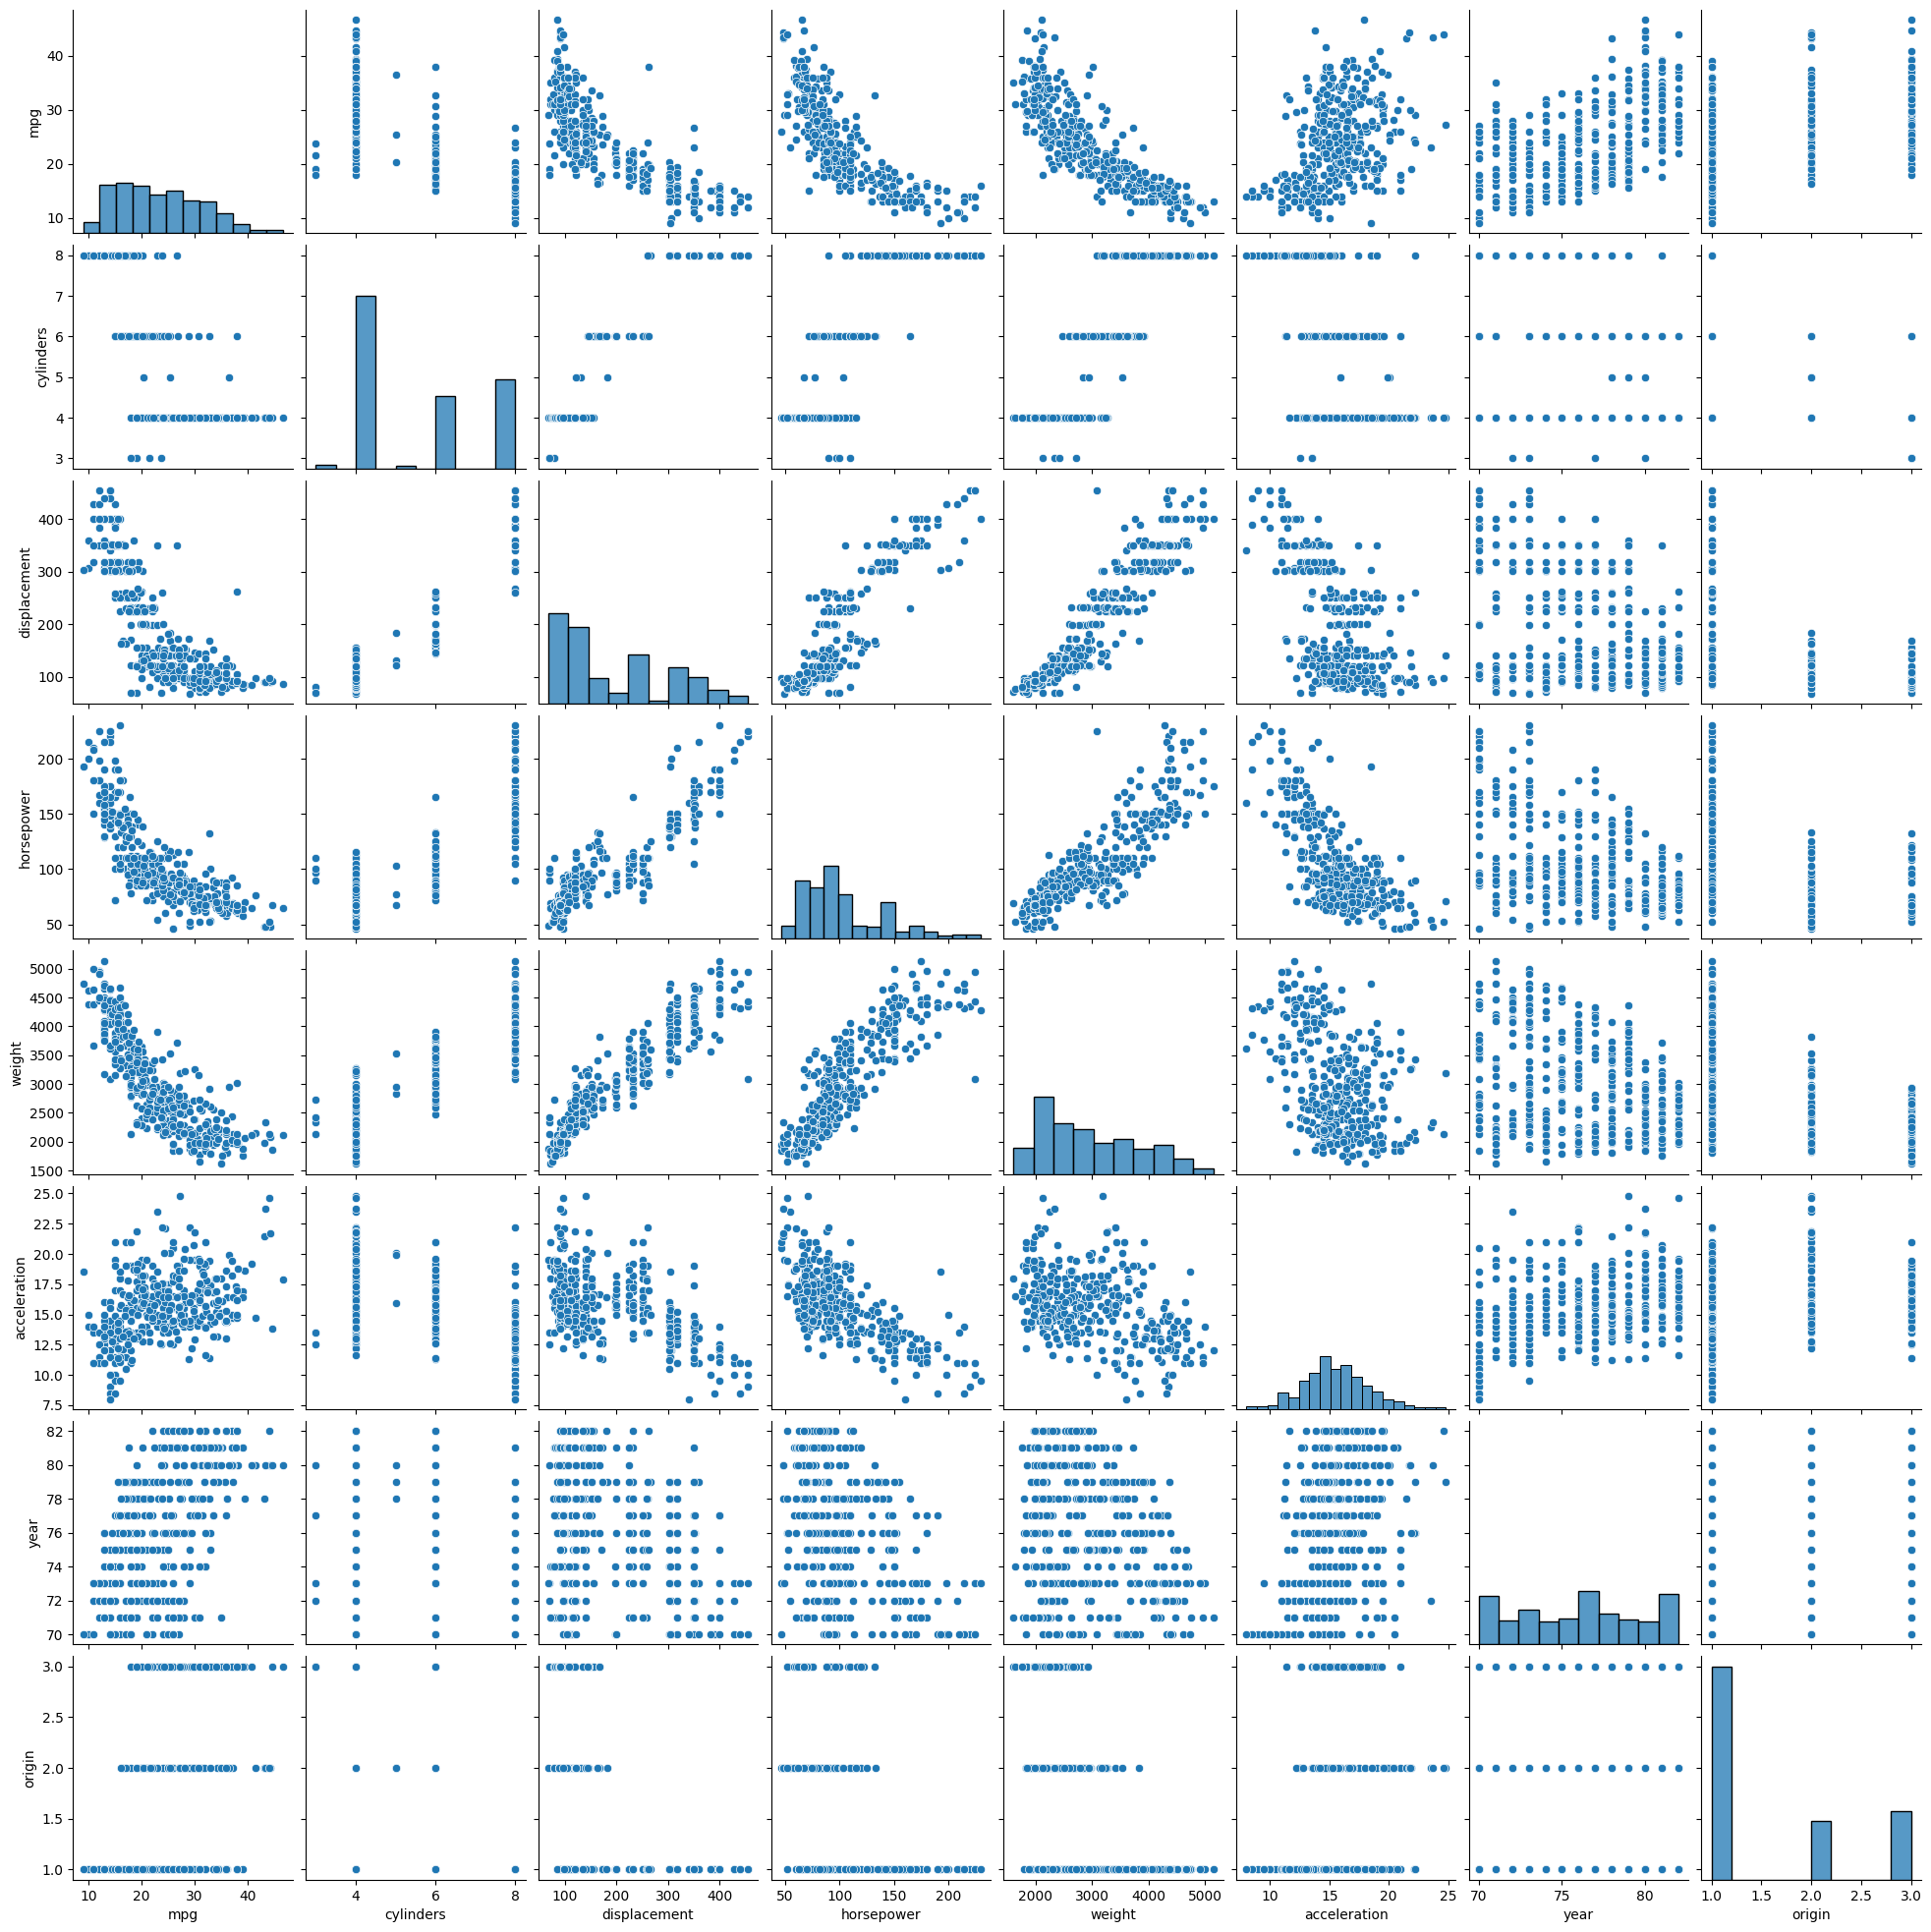

In [17]:
import seaborn as sns
sns.pairplot(df)
plt.show()

In [18]:
df["power_to_weight"] = df["horsepower"] / df["weight"]
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,power_to_weight
0,18.0,8,307.0,130,3504,12.0,70,1,0.037100
1,15.0,8,350.0,165,3693,11.5,70,1,0.044679
2,18.0,8,318.0,150,3436,11.0,70,1,0.043655
3,16.0,8,304.0,150,3433,12.0,70,1,0.043694
4,17.0,8,302.0,140,3449,10.5,70,1,0.040591


In [19]:
df["engine_load"] = df["displacement"] / df["cylinders"]
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,power_to_weight,engine_load
0,18.0,8,307.0,130,3504,12.0,70,1,0.037100,38.375
1,15.0,8,350.0,165,3693,11.5,70,1,0.044679,43.750
2,18.0,8,318.0,150,3436,11.0,70,1,0.043655,39.750
3,16.0,8,304.0,150,3433,12.0,70,1,0.043694,38.000
4,17.0,8,302.0,140,3449,10.5,70,1,0.040591,37.750


In [20]:
df["car_age"] = 126 - df["year"]
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,power_to_weight,engine_load,car_age
0,18.0,8,307.0,130,3504,12.0,70,1,0.037100,38.375,56
1,15.0,8,350.0,165,3693,11.5,70,1,0.044679,43.750,56
2,18.0,8,318.0,150,3436,11.0,70,1,0.043655,39.750,56
3,16.0,8,304.0,150,3433,12.0,70,1,0.043694,38.000,56
4,17.0,8,302.0,140,3449,10.5,70,1,0.040591,37.750,56


In [21]:
df.corr()["mpg"].sort_values(ascending = False)

mpg                1.000000
year               0.580541
origin             0.565209
acceleration       0.423329
power_to_weight   -0.269699
car_age           -0.580541
engine_load       -0.772536
cylinders         -0.777618
horsepower        -0.778427
displacement      -0.805127
weight            -0.832244
Name: mpg, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split

X_base = df.drop(columns = ["mpg", "power_to_weight", "engine_load", "car_age"])
y = df["mpg"]

X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size = 0.25, random_state = 42)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr_base = LinearRegression()
lr_base.fit(X_train_b, y_train)

y_pred_base = lr_base.predict(X_test_b)
mae_base =mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

mae_base, rmse_base, r2_base

(2.4086084030069332, np.float64(3.184738365223655), 0.7988908872869827)

In [24]:
X_fe = df.drop(columns = ["mpg"])

X_train_f, X_test_f, y_train, y_test = train_test_split(X_fe, y, test_size = 0.25, random_state = 42)

lr_fe = LinearRegression()
lr_fe.fit(X_train_f, y_train )

y_pred_f = lr_fe.predict(X_test_f)
mae_f = mean_absolute_error(y_test, y_pred_f)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred_f))
r2_f = r2_score(y_test, y_pred_f)
mae_f, rmse_f, r2_f

(2.213985253842008, np.float64(2.9578634661500467), 0.8265235696361323)

In [25]:
X = df.drop(columns = ["mpg"])
y = df["mpg"]

In [26]:
from sklearn.model_selection import train_test_split
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [27]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias = False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [28]:
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

y_pred_poly = lr_poly.predict(X_test_poly)


In [29]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

mae_poly, rmse_poly, r2_poly

(1.8996047829433982, np.float64(2.592085640271023), 0.8667758607901705)

In [30]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model": ["Baseline Linear Regression",
              "Feature Engineering Linear Regression",
              "Polynomial Regression"],
    "MAE": [mae_base, mae_f, mae_poly],
    "RMSE": [rmse_base, rmse_f, rmse_poly],
    "R2": [r2_base, r2_f, r2_poly]

})
final_comparison

,Model,MAE,RMSE,R2
0,Baseline Linear Regression,2.408608,3.184738,0.798891
1,Feature Engineering Linear Regression,2.213985,2.957863,0.826524
2,Polynomial Regression,1.899605,2.592086,0.866776


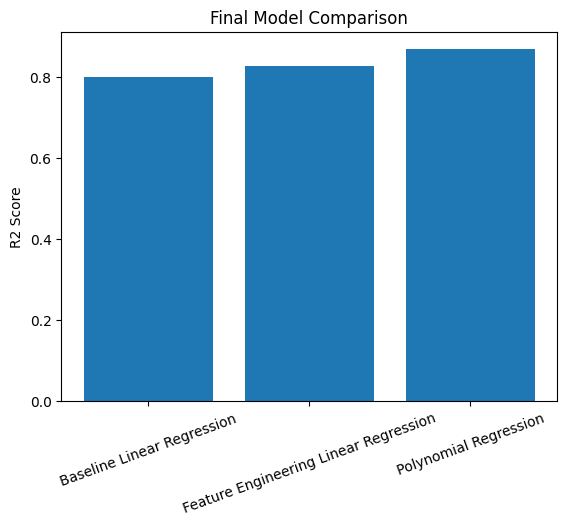

In [38]:
import matplotlib.pyplot as plt

plt.bar(
    final_comparison["Model"],
    final_comparison["R2"]
)
plt.ylabel("R2 Score")
plt.title("Final Model Comparison")
plt.xticks(rotation = 20)
plt.show()